# Forecasting Notebook


In [1]:
print("""
===================================
Xecomerce Demand Forecasting
===================================
""")


Xecomerce Demand Forecasting



In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style(
    "whitegrid"
)

In [3]:
orders = pd.read_csv(
    "../datasets/orders.csv"
)

print(
    f"Total Orders: {len(orders)}"
)

Total Orders: 99441


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [6]:
orders[
    "order_purchase_timestamp"
] = pd.to_datetime(
    orders[
        "order_purchase_timestamp"
    ]
)

In [7]:
orders["date"] = (
    orders[
        "order_purchase_timestamp"
    ].dt.date
)

orders["month"] = (
    orders[
        "order_purchase_timestamp"
    ].dt.month
)

orders["year"] = (
    orders[
        "order_purchase_timestamp"
    ].dt.year
)

orders["weekday"] = (
    orders[
        "order_purchase_timestamp"
    ].dt.day_name()
)

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,date,month,year,weekday
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10-02,10,2017,Monday
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07-24,7,2018,Tuesday
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08-08,8,2018,Wednesday
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11-18,11,2017,Saturday
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02-13,2,2018,Tuesday


In [8]:
daily_orders = (
    orders.groupby(
        "date"
    )
    .size()
    .reset_index(
        name="orders"
    )
)

daily_orders.head()

,date,orders
0,2016-09-04,1
1,2016-09-05,1
2,2016-09-13,1
3,2016-09-15,1
4,2016-10-02,1


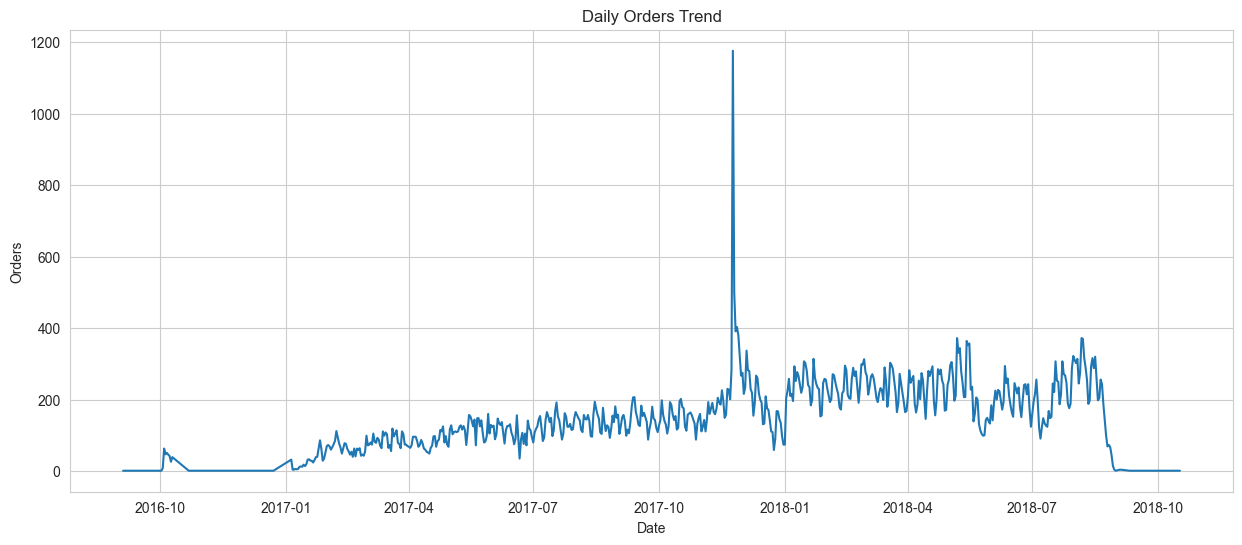

In [9]:
plt.figure(
    figsize=(15,6)
)

plt.plot(
    daily_orders["date"],
    daily_orders["orders"]
)

plt.title(
    "Daily Orders Trend"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Orders"
)

plt.show()

In [10]:
monthly_orders = (
    orders.groupby(
        "month"
    )
    .size()
    .reset_index(
        name="orders"
    )
)

monthly_orders

,month,orders
0,1,8069
1,2,8508
2,3,9893
3,4,9343
4,5,10573
5,6,9412
6,7,10318
7,8,10843
8,9,4305
9,10,4959


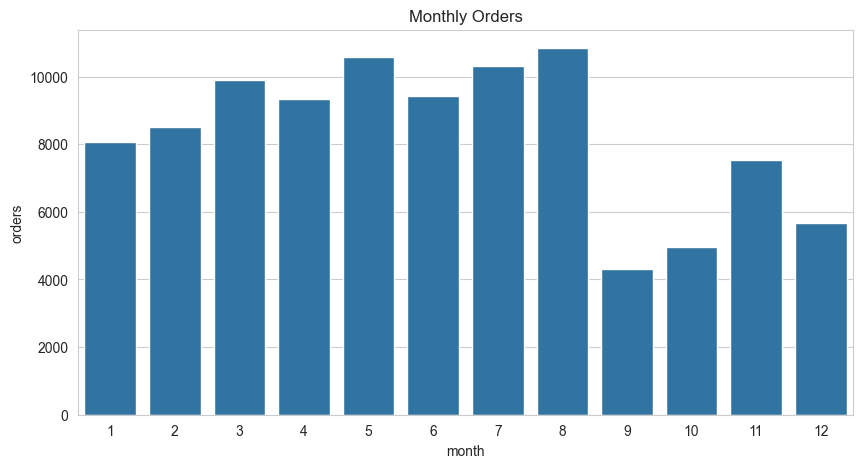

In [11]:
plt.figure(
    figsize=(10,5)
)

sns.barplot(
    data=monthly_orders,
    x="month",
    y="orders"
)

plt.title(
    "Monthly Orders"
)

plt.show()

In [12]:
weekday_orders = (
    orders.groupby(
        "weekday"
    )
    .size()
    .reset_index(
        name="orders"
    )
)

weekday_orders

,weekday,orders
0,Friday,14122
1,Monday,16196
2,Saturday,10887
3,Sunday,11960
4,Thursday,14761
5,Tuesday,15963
6,Wednesday,15552


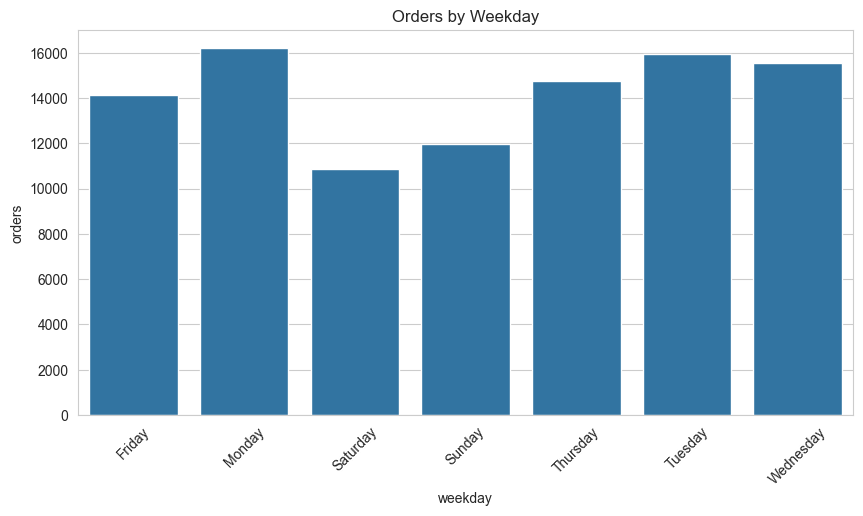

In [13]:
plt.figure(
    figsize=(10,5)
)

sns.barplot(
    data=weekday_orders,
    x="weekday",
    y="orders"
)

plt.xticks(
    rotation=45
)

plt.title(
    "Orders by Weekday"
)

plt.show()

In [14]:
orders[
    "order_status"
].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

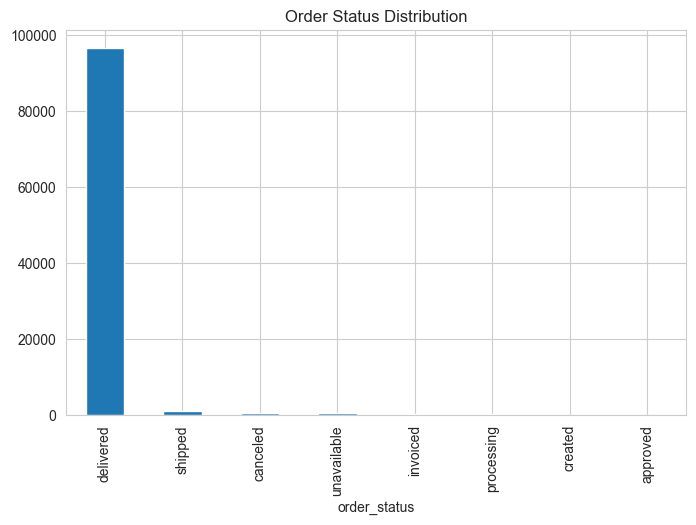

In [15]:
plt.figure(
    figsize=(8,5)
)

orders[
    "order_status"
].value_counts() \
.plot(
    kind="bar"
)

plt.title(
    "Order Status Distribution"
)

plt.show()

In [16]:
daily_orders = (
    daily_orders.sort_values(
        "date"
    )
)

daily_orders.reset_index(
    drop=True,
    inplace=True
)

daily_orders[
    "day_number"
] = daily_orders.index

daily_orders.head()

,date,orders,day_number
0,2016-09-04,1,0
1,2016-09-05,1,1
2,2016-09-13,1,2
3,2016-09-15,1,3
4,2016-10-02,1,4


In [17]:
model = joblib.load(
    "../saved_models/demand_forecast.pkl"
)

print(
    model
)

RandomForestRegressor(max_depth=15, n_estimators=300, n_jobs=-1,
                      random_state=42)


In [18]:
future_days = []

last_day = (
    daily_orders[
        "day_number"
    ].max()
)

last_date = pd.to_datetime(
    daily_orders[
        "date"
    ].max()
)

for i in range(1, 31):

    future_date = (
        last_date
        + pd.Timedelta(days=i)
    )

    future_days.append(
        {
            "day_number":
            last_day + i,

            "day_of_week":
            future_date.dayofweek,

            "month":
            future_date.month,

            "week_of_year":
            future_date.isocalendar().week
        }
    )

future_df = pd.DataFrame(
    future_days
)

future_df.head()

,day_number,day_of_week,month,week_of_year
0,634,3,10,42
1,635,4,10,42
2,636,5,10,42
3,637,6,10,42
4,638,0,10,43


In [19]:
future_predictions = (
    model.predict(
        future_df
    )
)

future_df[
    "predicted_orders"
] = future_predictions

future_df.head()

,day_number,day_of_week,month,week_of_year,predicted_orders
0,634,3,10,42,293.046667
1,635,4,10,42,245.550000
2,636,5,10,42,188.460000
3,637,6,10,42,199.310000
4,638,0,10,43,335.270000


In [20]:
future_df[
    [
        "predicted_orders"
    ]
].head(10)

,predicted_orders
0,293.046667
1,245.550000
2,188.460000
3,199.310000
4,335.270000
5,325.896667
6,317.103333
7,293.046667
8,245.550000
9,188.460000


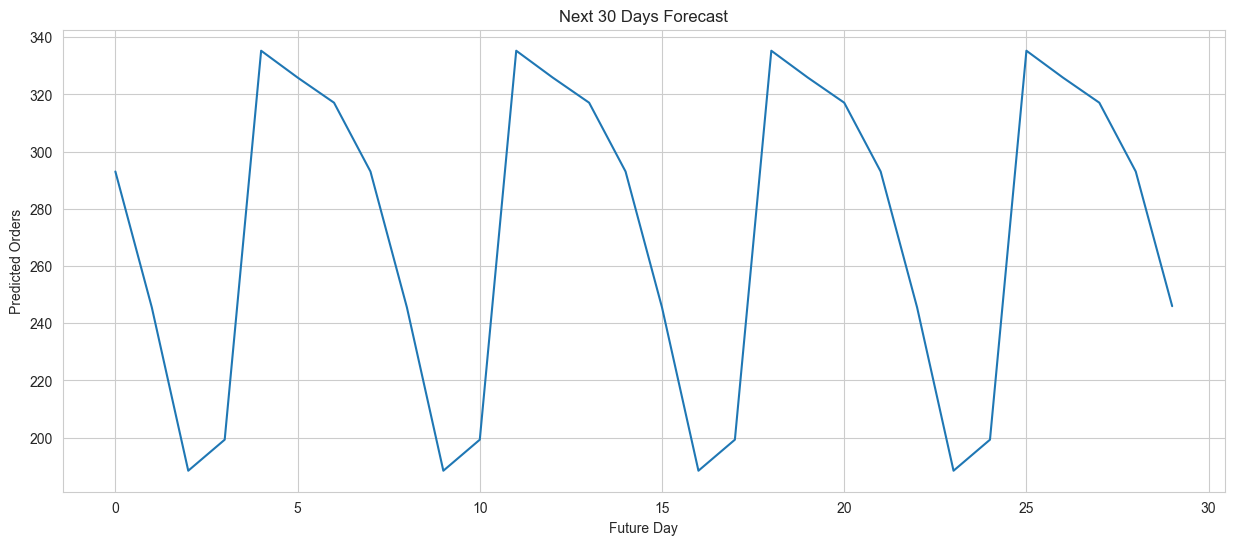

In [21]:
plt.figure(
    figsize=(15,6)
)

plt.plot(
    future_df.index,
    future_df[
        "predicted_orders"
    ]
)

plt.title(
    "Next 30 Days Forecast"
)

plt.xlabel(
    "Future Day"
)

plt.ylabel(
    "Predicted Orders"
)

plt.show()

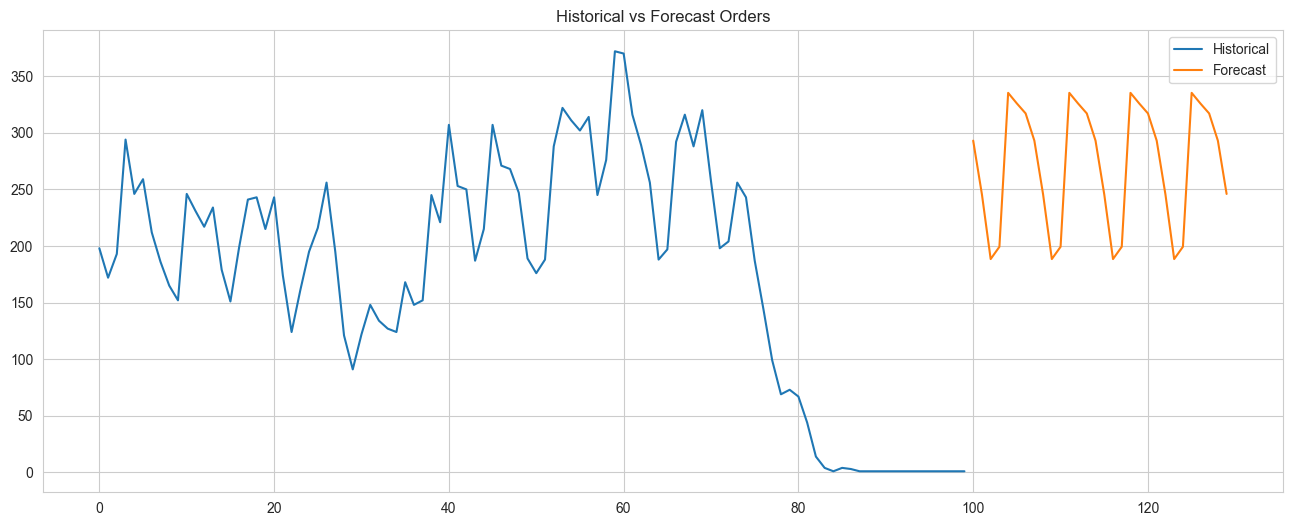

In [22]:
plt.figure(
    figsize=(16,6)
)

plt.plot(
    daily_orders[
        "orders"
    ].tail(100).values,
    label="Historical"
)

forecast_index = range(
    100,
    130
)

plt.plot(
    forecast_index,
    future_df[
        "predicted_orders"
    ],
    label="Forecast"
)

plt.legend()

plt.title(
    "Historical vs Forecast Orders"
)

plt.show()

In [23]:
print(
    "Minimum Forecast:",
    int(
        future_df[
            "predicted_orders"
        ].min()
    )
)

print(
    "Maximum Forecast:",
    int(
        future_df[
            "predicted_orders"
        ].max()
    )
)

print(
    "Average Forecast:",
    int(
        future_df[
            "predicted_orders"
        ].mean()
    )
)

Minimum Forecast: 188
Maximum Forecast: 335
Average Forecast: 271


In [24]:
future_df.sort_values(
    by="predicted_orders",
    ascending=False
).head(10)

,day_number,day_of_week,month,week_of_year,predicted_orders
4,638,0,10,43,335.270000
11,645,0,10,44,335.270000
25,659,0,11,46,335.270000
18,652,0,11,45,335.270000
26,660,1,11,46,325.900000
12,646,1,10,44,325.896667
19,653,1,11,45,325.896667
5,639,1,10,43,325.896667
27,661,2,11,46,317.106667
20,654,2,11,45,317.103333


In [25]:
future_df.to_csv(
    "../saved_models/future_demand_forecast.csv",
    index=False
)

print(
    "Forecast Saved Successfully"
)

Forecast Saved Successfully


In [26]:
import os

os.listdir(
    "../saved_models"
)

['chatbot_index.pkl',
 'dataset_profiles.pkl',
 'demand_forecast.pkl',
 'fake_review.pkl',
 'fake_review_vectorizer.pkl',
 'future_demand_forecast.csv',
 'price_predictor.pkl',
 'products.faiss',
 'products.faiss.meta',
 'recommendation_similarity.pkl',
 'recommendation_vectorizer.pkl',
 'recommender.pkl',
 'sentiment.pkl',
 'sentiment_vectorizer.pkl']

In [27]:
print("""
Forecasting Notebook Completed

✔ Orders Dataset Loaded
✔ Daily Orders Analyzed
✔ Monthly Trends Analyzed
✔ Weekday Trends Analyzed
✔ Forecast Model Loaded
✔ Next 30 Days Predicted
✔ Forecast Saved

Xecomerce Notebook Series Completed
""")


Forecasting Notebook Completed

✔ Orders Dataset Loaded
✔ Daily Orders Analyzed
✔ Monthly Trends Analyzed
✔ Weekday Trends Analyzed
✔ Forecast Model Loaded
✔ Next 30 Days Predicted
✔ Forecast Saved

Xecomerce Notebook Series Completed

